In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [13]:
df = pd.read_csv("hour.csv")
df = df.dropna()


In [14]:
print(df.head())
print(df.info())
print(df.shape)

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  01-01-2011       1   0     1   0        0        6           0   
1        2  01-01-2011       1   0     1   1        0        6           0   
2        3  01-01-2011       1   0     1   2        0        6           0   
3        4  01-01-2011       1   0     1   3        0        6           0   
4        5  01-01-2011       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 

In [15]:
X = df.drop(['cnt', 'dteday', 'instant', 'casual', 'registered'], axis=1)
y = df['cnt']

In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17379, 12)
y shape: (17379,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (13903, 12)
Test shape: (3476, 12)


In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsRegressor()

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 11116.111507479862
R2 Score: 0.6489509834763534


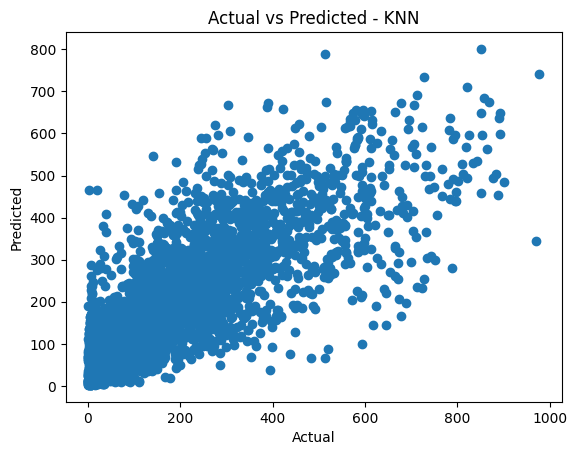

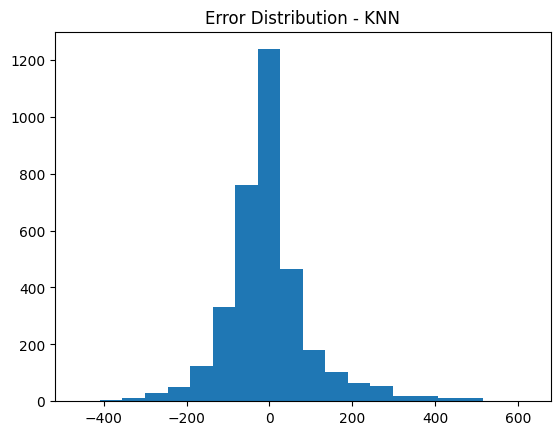

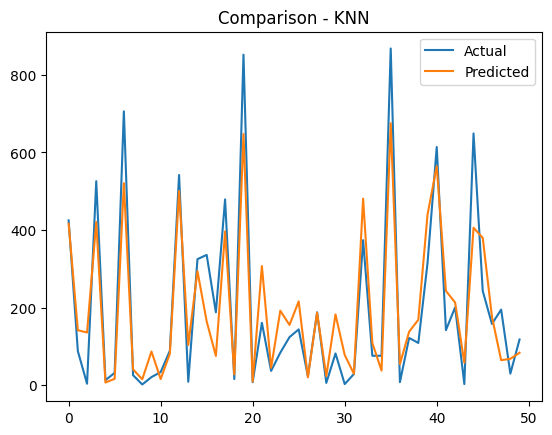

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - KNN")
plt.show()

errors = y_test - y_pred

plt.hist(errors, bins=20)
plt.title("Error Distribution - KNN")
plt.show()

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.legend()
plt.title("Comparison - KNN")
plt.show()